## Analisis Exploratorio de datos (Vista Minable)
- Autor: Germán Homero Moran Figueroa
- Descripción: En este Notebbok se realiza un analisis exploratorio de los datos y variables que conforman la vista minable: Indentificacando valores nulos, atipicos, diagramas de correlación , entre otros.
- Salida: EDA vista Minable

In [4]:
# Librerias y Depenendencias
# ===========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot       as plt
import seaborn                 as sns
import statsmodels.formula.api as sm
from   scipy import stats

In [5]:
# Cargue de los datos | informacion
# ======================================================
df = pd.read_excel("../../Data/Gold/DatasetFinal.xlsx")
print("Longitud: ", df.shape)
df.head(5)

Longitud:  (799, 116)


,ID_LOTE,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,...,Temp_Max_Avg_Mad,Temp_Min_Avg_Mad,Temp_Avg_Mad,Diurnal_Range_Avg_Mad,Sol_Ener_Accu_Mad,Temp_Max_34_Freq_Mad,Rain_Accu_Mad,Rain_10_Freq_Mad,Rhum_Avg_Mad,RDT_AJUSTADO
0,40,Mecanizado,NO,PIONEER 30F32,Algodon,SI,Manual,NO,5,63,...,32.05,23.60,27.83,8.45,13197.57,0.05,279.3,0.23,82.41,4767.44
1,43,Mecanizado,SI,DK 234,Maiz,SI,Manual,NO,5,64,...,32.37,23.49,27.93,8.89,12436.49,0.03,221.2,0.26,81.86,4651.16
2,44,Mecanizado,NO,PIONEER 30F32,Algodon,SI,Manual,NO,5,59,...,32.17,23.53,27.85,8.63,11267.17,0.03,226.0,0.27,82.61,5180.23
3,45,Mecanizado,NO,Otro,Algodon,SI,Manual,NO,5,64,...,32.19,23.54,27.86,8.65,11066.68,0.03,223.2,0.29,81.84,4897.67
4,46,Mecanizado,NO,Otro,Algodon,SI,Manual,NO,5,63,...,32.19,23.54,27.86,8.65,11066.68,0.03,223.2,0.29,81.84,5302.33


In [6]:
# Cantida de Nulos
# ======================================
nulos = df.isnull().sum().reset_index(drop=True).sort_index(ascending=True)
nulos

0      0
1      0
2      0
3      0
4      0
      ..
111    0
112    0
113    0
114    0
115    0
Length: 116, dtype: int64

**Nota** Al verificar los nulos que existen en la vista minable, se observa que no existen nulos considerables. Por tal motivo, se procece al analisis de correlaciones para cada grupo de variables

In [7]:
# Tipos de datos del datset [Variables categoricas Ordinales | nominales | binarias codificacion]
# ================================================================================================
print(df.dtypes)

ID_LOTE                   int64
TIPO_SIEMBRA             object
SEM_TRATADAS             object
MATERIAL_GENETICO        object
CULT_ANT                 object
                         ...   
Temp_Max_34_Freq_Mad    float64
Rain_Accu_Mad           float64
Rain_10_Freq_Mad        float64
Rhum_Avg_Mad            float64
RDT_AJUSTADO            float64
Length: 116, dtype: object


<AxesSubplot:>

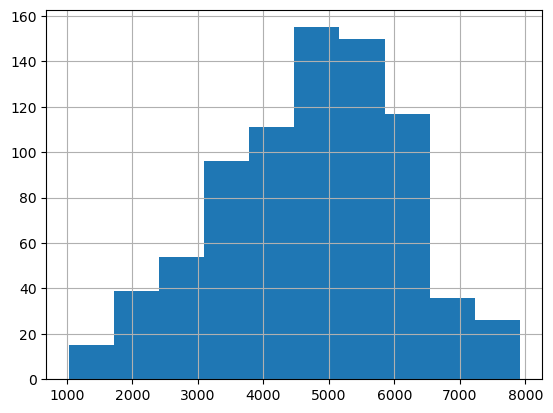

In [8]:
# Distribución de la Variable Objetivo Rendimiento
# ===================================================================================
df.RDT_AJUSTADO.hist()

In [9]:
# Analisis de variables segun el tipo
# ==============================================================================
variables_generales = ['TIPO_SIEMBRA','SEM_TRATADAS','MATERIAL_GENETICO','CULT_ANT','DRENAJE','METODO_COSECHA',
 'ALMACENAMIENTO_FINCA','DIAS_EN_EMERGER','DIAS_EN_EMERGER_A_FLORECER','DIAS_EN_FLORECER_A_COSECHAR',
 'POBLACION_20DIAS_AJT','ALTURA_LOT']

variables_practicas_manejo = ['ContEnfQui_Emer_Flor', 'ContEnfQui_Flor_Cose', 'ContMalMec_Siem_Emer','ContMalMec_Emer_Flor',
 'ContMalMec_Flor_Cose','ContMalQui_Antes_Siem','ContMalQui_Siem_Emer','ContMalQui_Emer_Flor','ContMalQui_Flor_Cose',
 'ContPlaQui_Antes_Siem','ContPlaQui_Siem_Emer','ContPlaQui_Emer_Flor','ContPlaQui_Flor_Cose' ,'TotN_Antes_Siem',
 'TotN_Siem_Emer','TotN_Emer_Flor', 'TotP_Antes_Siem','TotP_Siem_Emer','TotP_Emer_Flor','TotK_Antes_Siem',
 'TotK_Siem_Emer','TotK_Emer_Flor','FerOrg_Emer_Flor','FerQui_Antes_Siem','FerQui_Siem_Emer','FerQui_Emer_Flor']


variables_suelo = ['PENDIENTE_RASTA','TERRENO_CIRCUN_RASTA','POSICION_PERFIL_RASTA','NO_CAPAS_RASTA','PH_RASTA',
 'PEDREG_PERFIL_ROCAS','CAP_ENDURE_RASTA','PROFUND_CAP_ENDURE_RASTA','ESPESOR_CAP_ENDURE_RASTA','MOTEADOS_RASTA',
 'PROFUND_MOTEADOS_RASTA','MOTEADOS_MAS70cm._RASTA','ESTRUCTURA_RASTA','OBSERVA_EROSION_RASTA','OBSERVA_MOHO_RASTA',
 'OBSERVA_COSTRAS_DURAS_RASTA', 'SITIO_EXPUESTO_SOL_RASTA', 'OBSERVA_COSTRAS_BLANCAS_RASTA','OBSERVA_COSTAS_NEGRAS_RASTA',
 'REGION_SECA_ARIDA_RASTA','OBSERVA_RAICES_VIVAS_RASTA','PROFUND_RAICES_VIVAS_RASTA','OBSERVA_PLANTAS_PEQUENAS_RASTA',
 'OBSERVA_HOJARASCA_MO_RASTA','SUELO_NEGRO_BLANDO_RASTA','CUCHILLO_PRIMER_HTE_RASTA','CERCA_RIOS_QUEBRADAS_RASTA',
 'RECUBRIMIENTO_VEGETAL__SUELO_RASTA','prof_efectiva','d.interno','drenaje_externo','Porc_A','Porc_Ar','Porc_ArA','Porc_ArL',
 'Porc_FrL','Porc_L','Porc_F','porc.x','porc.y','Porc_AF','Porc_BLANDO','Porc_DURO','Porc_EXT_DURO','Porc_FRIABLE',
 'Porc_FIRME','Porc_EXT_FIRME','Porc_PLASTICO','Porc_MUY_PLASTICO']

variables_clima = [
 'Temp_Max_Avg_Veg','Temp_Min_Avg_Veg', 'Temp_Avg_Veg', 'Diurnal_Range_Avg_Veg', 'Sol_Ener_Accu_Veg', 'Temp_Max_34_Freq_Veg',
 'Rain_Accu_Veg', 'Rain_10_Freq_Veg', 'Rhum_Avg_Veg', 'Temp_Max_Avg_For', 'Temp_Min_Avg_For', 'Temp_Avg_For',
 'Diurnal_Range_Avg_For', 'Sol_Ener_Accu_For', 'Temp_Max_34_Freq_For', 'Rain_Accu_For', 'Rain_10_Freq_For', 'Rhum_Avg_For', 'Temp_Max_Avg_Mad',
 'Temp_Min_Avg_Mad', 'Temp_Avg_Mad', 'Diurnal_Range_Avg_Mad', 'Sol_Ener_Accu_Mad', 'Temp_Max_34_Freq_Mad', 'Rain_Accu_Mad',
 'Rain_10_Freq_Mad', 'Rhum_Avg_Mad'
]



### 1. Obtenemos un resumen de c/d grupo de variables

En este primer apartado se busca identificar posibles correlaciones entre los diferentes conjutos de variables
que conforman la vista minable. 
- Se tienen variables Generales [Continuas y categoricas]
- Se tienen variables de Suelo [Continuas y categoricas]
- Se tienen variables de Clima [Continuas y categoricas]
- Se tienen variables Parcticas de manejo Agricola [Continuas y categoricas]


In [10]:
# 1. VARIABLES GENERALES
# ===========================================================
summary_categorical_features_vg = df[variables_generales].describe(include="object")
summary_categorical_features_vg


,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA
count,799,799,799,799,799,799,799
unique,2,2,27,5,2,2,2
top,Mecanizado,NO,Otro,Algodon,SI,Manual,NO
freq,556,456,240,420,470,561,617


In [11]:
summary_numerical_features_vg = df[variables_generales].describe()
summary_numerical_features_vg 

,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT
count,799.000000,799.000000,799.000000,799.000000,799.000000
mean,5.003755,47.624531,80.803504,63886.640801,12.211514
std,1.329720,4.990136,8.632148,7696.846635,9.168108
min,0.000000,26.000000,46.000000,6000.000000,2.000000
25%,4.000000,46.000000,77.000000,60000.000000,7.000000
50%,5.000000,47.000000,82.000000,62500.000000,10.000000
75%,5.000000,49.000000,85.000000,70000.000000,16.000000
max,15.000000,85.000000,113.000000,87500.000000,79.000000


Text(0.5, 1.0, 'Mapa de Calor correlaciones para [Variables Generales]')

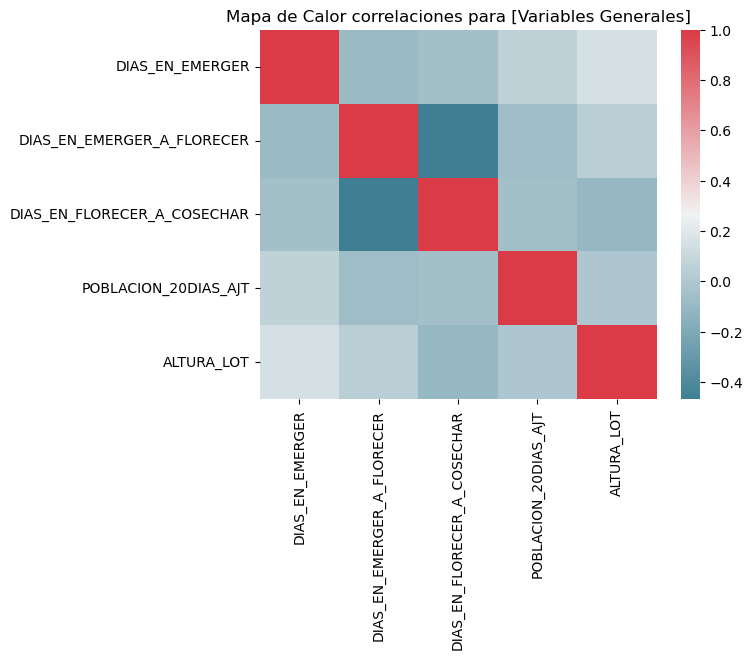

In [12]:
# Se calcula la matriz de correlacion
# =================================================================================
cols =  df[variables_generales].select_dtypes(include = ["float64","int64"]).columns
mat_corr_vg = df[cols].corr()
sns.heatmap(mat_corr_vg ,cmap=sns.diverging_palette(220, 10, as_cmap=True))
plt.title("Mapa de Calor correlaciones para [Variables Generales]")

*Nota* No se observan altas correlaciones para las variables numericas relacionadas con la información general de los cultivos, por tal motivo se decide mantener todas estas variables.

In [13]:
# Variables practicas de manejo 
# =========================================
summary_numerical_features_pm = df[variables_practicas_manejo].describe()
summary_numerical_features_pm 

,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,...,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor
count,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,...,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000
mean,0.155194,0.018773,0.001252,0.006258,0.003755,0.111389,0.475594,0.988736,0.027534,0.045056,...,0.030038,1.324093,1.904506,0.052566,1.553004,18.367209,0.002503,0.011264,0.131414,2.500626
std,0.425909,0.135809,0.035377,0.078908,0.061199,0.386304,0.702015,0.607904,0.178388,0.207558,...,0.849059,5.425735,6.011944,1.142587,6.757624,25.265127,0.050000,0.136638,0.465880,0.988499
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,3.000000
max,3.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,4.000000,2.000000,1.000000,...,24.000000,40.000000,47.500000,30.000000,75.000000,180.000000,1.000000,3.000000,3.000000,7.000000


Text(0.5, 1.0, 'Mapa de Calor correlaciones para [Variables Parcaticas Manejo]')

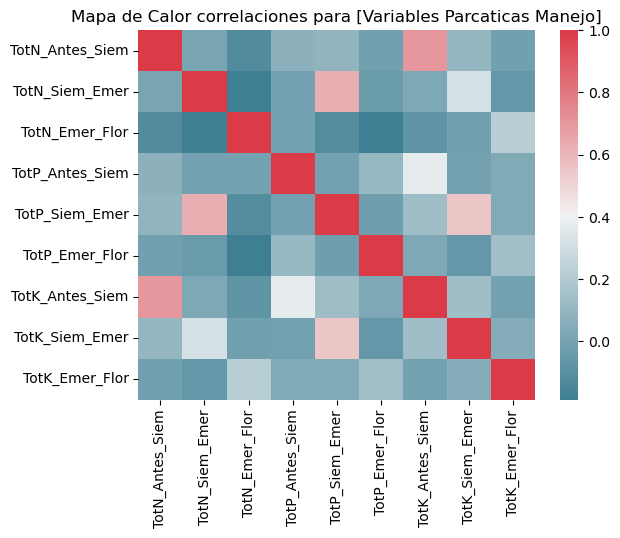

In [14]:
# Se calcula la matriz de correlacion
# ==================================================================================================
cols_npk = ['TotN_Antes_Siem', 'TotN_Siem_Emer','TotN_Emer_Flor', 'TotP_Antes_Siem',
            'TotP_Siem_Emer','TotP_Emer_Flor','TotK_Antes_Siem','TotK_Siem_Emer','TotK_Emer_Flor' ]
cols =  df[cols_npk].columns
mat_corr_vpm = df[cols].corr()
sns.heatmap(mat_corr_vpm ,cmap=sns.diverging_palette(220, 10, as_cmap=True))
plt.title("Mapa de Calor correlaciones para [Variables Parcaticas Manejo]")

In [15]:
mat_corr_vpm 

,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor
TotN_Antes_Siem,1.000000,0.009581,-0.125050,0.073068,0.089064,-0.017209,0.700870,0.095400,-0.017497
TotN_Siem_Emer,0.009581,1.000000,-0.184000,-0.007518,0.626758,-0.041497,0.024837,0.311447,-0.061557
TotN_Emer_Flor,-0.125050,-0.184000,1.000000,-0.003360,-0.114468,-0.187846,-0.075736,-0.018803,0.219385
TotP_Antes_Siem,0.073068,-0.007518,-0.003360,1.000000,-0.008644,0.106617,0.370387,-0.008140,0.037339
TotP_Siem_Emer,0.089064,0.626758,-0.114468,-0.008644,1.000000,-0.025158,0.128234,0.552741,0.036812
TotP_Emer_Flor,-0.017209,-0.041497,-0.187846,0.106617,-0.025158,1.000000,0.029191,-0.058088,0.145144
TotK_Antes_Siem,0.700870,0.024837,-0.075736,0.370387,0.128234,0.029191,1.000000,0.135482,-0.010046
TotK_Siem_Emer,0.095400,0.311447,-0.018803,-0.008140,0.552741,-0.058088,0.135482,1.000000,0.049467
TotK_Emer_Flor,-0.017497,-0.061557,0.219385,0.037339,0.036812,0.145144,-0.010046,0.049467,1.000000


**Nota** En este caso solo se analizan las variables relacionadas a la aplicacion de  (NPK), dado que las otras variables relacionadas al numero de controles quimicos y organicos son variables numericas, discretas. Tienen asociados valores especificos. A pesar de que algunas variables tienen alta correlación ( 0.7), se consideran que tienen correlación moderada . En este caso  no se elimina, se considera eliminar variables que unicamente tengan correlaciones por encima de  0. 8 , dado que estas variables pueden causar colinealidad y afectar el desempeño del modelo.

In [16]:
# Variables del suelo [categoricas]
# =======================================================================================
summary_categorical_features_vs = df[variables_suelo].describe(include="object")
summary_categorical_features_vs


,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,PEDREG_PERFIL_ROCAS,CAP_ENDURE_RASTA,MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,...,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,d.interno,drenaje_externo
count,799,799,799,799,799,799,799,799,799,799,...,799,799,799,799,799,799,799,799,799,799
unique,3,6,2,2,2,2,4,2,2,3,...,2,2,4,2,2,2,2,5,3,2
top,PLANO O LLANO,PLANO,SIN ROCAS,NO,NO,NO,GRANULAR,NO,NO,NO HAY,...,NO,SI,PLANTAS NORMALES,NO,NO,SI,NO,REGULAR,BUENO,NINGUNO
freq,775,769,798,696,457,775,386,797,792,732,...,787,767,615,526,797,694,599,280,465,508


Text(0.5, 1.0, 'Mapa de Calor correlaciones para [Variables del Suelo Textura y Resistencia]')

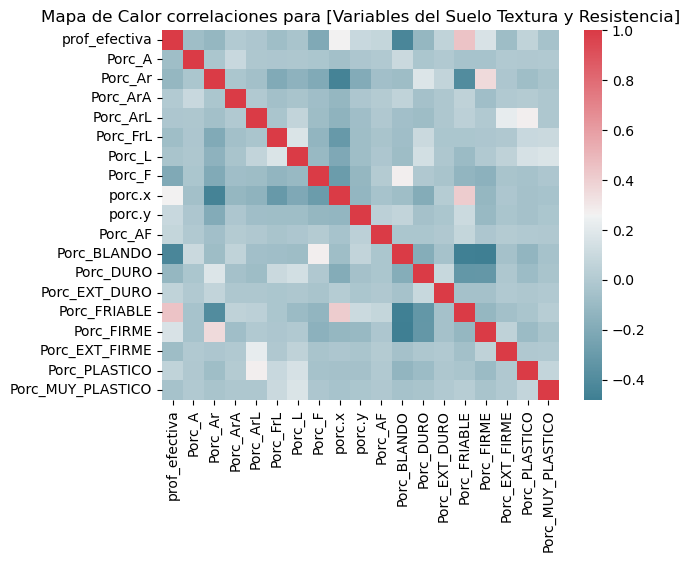

In [17]:

# Analisis variables numericas [TEXTURA y RESISTENCIA AL ROMPIMIENTO]
# ======================================================================================================
var_suelo_text_rest = ['prof_efectiva','Porc_A','Porc_Ar','Porc_ArA','Porc_ArL','Porc_FrL',
                       'Porc_L','Porc_F','porc.x','porc.y','Porc_AF','Porc_BLANDO','Porc_DURO',
                       'Porc_EXT_DURO','Porc_FRIABLE','Porc_FIRME','Porc_EXT_FIRME','Porc_PLASTICO',
                       'Porc_MUY_PLASTICO']



mat_corr_vs = df[var_suelo_text_rest].corr()
sns.heatmap(mat_corr_vs ,cmap=sns.diverging_palette(220, 10, as_cmap=True))
plt.title("Mapa de Calor correlaciones para [Variables del Suelo Textura y Resistencia]")

**Nota** En este caso no se observa ninguna variable altamente correlacionada por tal motivo se decidio conservar todas las variables para el modelado.

In [18]:
# Variables de Clima
# ================================================
summary_numerical_features_vc = df[variables_clima].describe()
summary_numerical_features_vc 

,Temp_Max_Avg_Veg,Temp_Min_Avg_Veg,Temp_Avg_Veg,Diurnal_Range_Avg_Veg,Sol_Ener_Accu_Veg,Temp_Max_34_Freq_Veg,Rain_Accu_Veg,Rain_10_Freq_Veg,Rhum_Avg_Veg,Temp_Max_Avg_For,...,Rhum_Avg_For,Temp_Max_Avg_Mad,Temp_Min_Avg_Mad,Temp_Avg_Mad,Diurnal_Range_Avg_Mad,Sol_Ener_Accu_Mad,Temp_Max_34_Freq_Mad,Rain_Accu_Mad,Rain_10_Freq_Mad,Rhum_Avg_Mad
count,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,...,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000,799.000000
mean,33.253992,24.424531,28.839387,8.830175,15210.583041,0.341640,234.544869,0.161652,81.232916,33.468974,...,80.791339,32.907885,23.802791,28.355194,9.105332,14321.927134,0.227084,128.684155,0.113554,81.077272
std,0.743965,0.404092,0.453421,0.782042,648.825944,0.165507,114.572327,0.070711,2.813697,0.601452,...,2.286649,0.786421,0.845999,0.687200,0.883446,3238.994249,0.222461,85.857060,0.073787,2.621140
min,31.760000,23.300000,27.690000,6.970000,13132.500000,0.000000,51.400000,0.050000,75.030000,32.130000,...,77.600000,31.670000,22.340000,27.090000,6.980000,2836.860000,0.000000,0.000000,0.000000,72.930000
25%,32.840000,24.180000,28.460000,8.640000,14804.760000,0.235000,134.700000,0.100000,79.890000,33.160000,...,78.920000,32.350000,22.935000,27.600000,8.660000,12446.780000,0.050000,56.250000,0.050000,79.720000
50%,33.270000,24.470000,28.820000,8.910000,15242.420000,0.400000,198.300000,0.150000,80.440000,33.290000,...,80.250000,32.710000,24.070000,28.670000,8.910000,14335.570000,0.140000,122.600000,0.120000,81.920000
75%,33.830000,24.750000,29.120000,9.100000,15505.820000,0.420000,337.900000,0.220000,81.850000,33.920000,...,82.215000,33.400000,24.540000,28.950000,9.755000,16198.090000,0.380000,179.300000,0.180000,82.445000
max,35.190000,25.240000,29.990000,11.750000,16959.890000,0.820000,426.400000,0.280000,89.140000,35.250000,...,87.140000,35.500000,25.140000,29.630000,12.160000,27398.410000,0.910000,390.300000,0.310000,87.830000


Text(0.5, 1.0, 'Mapa de Calor correlaciones para [Variables Clima]')

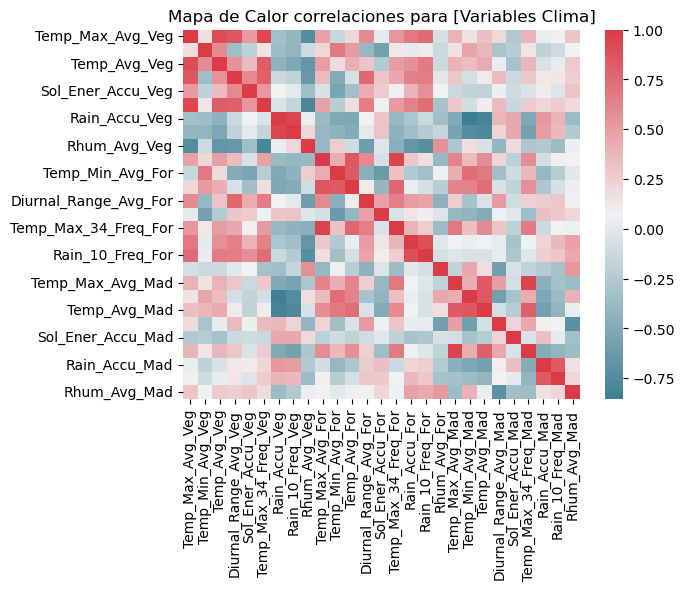

In [19]:
# Se calcula la matriz de correlacion variables clima
# ==================================================================================================
cols =  df[variables_clima].columns
mat_corr_vc= df[cols].corr()
sns.heatmap(mat_corr_vc ,cmap=sns.diverging_palette(220, 10, as_cmap=True))
plt.title("Mapa de Calor correlaciones para [Variables Clima]")

In [20]:
mat_corr_vc

,Temp_Max_Avg_Veg,Temp_Min_Avg_Veg,Temp_Avg_Veg,Diurnal_Range_Avg_Veg,Sol_Ener_Accu_Veg,Temp_Max_34_Freq_Veg,Rain_Accu_Veg,Rain_10_Freq_Veg,Rhum_Avg_Veg,Temp_Max_Avg_For,...,Rhum_Avg_For,Temp_Max_Avg_Mad,Temp_Min_Avg_Mad,Temp_Avg_Mad,Diurnal_Range_Avg_Mad,Sol_Ener_Accu_Mad,Temp_Max_34_Freq_Mad,Rain_Accu_Mad,Rain_10_Freq_Mad,Rhum_Avg_Mad
Temp_Max_Avg_Veg,1.000000,0.175611,0.898726,0.861141,0.521357,0.928275,-0.328019,-0.411648,-0.744495,0.475359,...,-0.080999,0.390660,0.158199,0.320871,0.196394,-0.259835,0.379125,0.031900,0.084188,0.303051
Temp_Min_Avg_Veg,0.175611,1.000000,0.589459,-0.349214,-0.192463,0.142237,-0.358835,-0.416528,-0.112564,0.215082,...,-0.124934,0.157778,0.459220,0.372949,-0.299472,-0.230925,0.142972,-0.184712,-0.105501,0.068889
Temp_Avg_Veg,0.898726,0.589459,1.000000,0.551056,0.342574,0.824968,-0.428918,-0.523101,-0.660567,0.485869,...,-0.121490,0.390716,0.334597,0.429488,0.027425,-0.315779,0.374656,-0.056278,0.021846,0.279607
Diurnal_Range_Avg_Veg,0.861141,-0.349214,0.551056,1.000000,0.595154,0.810008,-0.127028,-0.176769,-0.650202,0.341275,...,-0.012036,0.290679,-0.086309,0.113161,0.341617,-0.127952,0.287230,0.125658,0.134599,0.252750
Sol_Ener_Accu_Veg,0.521357,-0.192463,0.342574,0.595154,1.000000,0.521716,0.074527,0.005621,-0.345525,-0.055077,...,0.069348,-0.126858,-0.169446,-0.177018,0.049456,-0.105070,-0.039862,0.109542,-0.035587,0.303567
Temp_Max_34_Freq_Veg,0.928275,0.142237,0.824968,0.810008,0.521716,1.000000,-0.043529,-0.162453,-0.796921,0.477373,...,-0.314830,0.285177,-0.090667,0.107306,0.340716,-0.132488,0.262114,0.212517,0.262283,0.186685
Rain_Accu_Veg,-0.328019,-0.358835,-0.428918,-0.127028,0.074527,-0.043529,1.000000,0.942423,0.037470,-0.382077,...,-0.339866,-0.501245,-0.855164,-0.813375,0.372574,0.447745,-0.513275,0.523076,0.381884,-0.371177
Rain_10_Freq_Veg,-0.411648,-0.416528,-0.523101,-0.176769,0.005621,-0.162453,0.942423,1.000000,0.209274,-0.393893,...,-0.157813,-0.554172,-0.749605,-0.778611,0.224328,0.445663,-0.577998,0.504739,0.355993,-0.257261
Rhum_Avg_Veg,-0.744495,-0.112564,-0.660567,-0.650202,-0.345525,-0.796921,0.037470,0.209274,1.000000,-0.388517,...,0.562914,-0.274190,0.170095,-0.052045,-0.407159,0.193434,-0.270383,-0.258213,-0.366270,0.044134
Temp_Max_Avg_For,0.475359,0.215082,0.485869,0.341275,-0.055077,0.477373,-0.382077,-0.393893,-0.388517,1.000000,...,-0.398360,0.624924,0.351922,0.574385,0.219210,-0.191704,0.574942,-0.088719,0.091957,0.076941


**Nota** Hay muchas variables con altas correlaciones > 0.8 pero debido a que nos tiene información por parte de lso expertos, de cuales eliminar y/o conservar se decidio conservar todas las variables.

###  1.1 Correlaciones Vista Minable
La correlación mide la relación lineal entre dos variables, si la correlacion resultante es 0 significa que las 2 variables no tiene ningun tipo de relacion lineal, pero puede tener otro tipo de relacion . La correlacion solo captura relaciones lineal, para capturar otro tipo de relaciones se requieren metodos mas  avanzados.
En este caso se analizan la correlación existente entre los diferentes grupos de variables

In [21]:
# Se seleccionan todas las variables numericas del DF
# ===========================================================================
numerical_features = df.select_dtypes(include = ["float64","int64"]).columns
print("Cantidad del variables numericas: ", len(numerical_features))
numerical_features

Cantidad del variables numericas:  86


Index(['ID_LOTE', 'DIAS_EN_EMERGER', 'DIAS_EN_EMERGER_A_FLORECER',
       'DIAS_EN_FLORECER_A_COSECHAR', 'POBLACION_20DIAS_AJT', 'ALTURA_LOT',
       'ContEnfQui_Emer_Flor', 'ContEnfQui_Flor_Cose', 'ContMalMec_Siem_Emer',
       'ContMalMec_Emer_Flor', 'ContMalMec_Flor_Cose', 'ContMalQui_Antes_Siem',
       'ContMalQui_Siem_Emer', 'ContMalQui_Emer_Flor', 'ContMalQui_Flor_Cose',
       'ContPlaQui_Antes_Siem', 'ContPlaQui_Siem_Emer', 'ContPlaQui_Emer_Flor',
       'ContPlaQui_Flor_Cose', 'TotN_Antes_Siem', 'TotN_Siem_Emer',
       'TotN_Emer_Flor', 'TotP_Antes_Siem', 'TotP_Siem_Emer', 'TotP_Emer_Flor',
       'TotK_Antes_Siem', 'TotK_Siem_Emer', 'TotK_Emer_Flor',
       'FerOrg_Emer_Flor', 'FerQui_Antes_Siem', 'FerQui_Siem_Emer',
       'FerQui_Emer_Flor', 'PENDIENTE_RASTA', 'NO_CAPAS_RASTA', 'PH_RASTA',
       'PROFUND_CAP_ENDURE_RASTA', 'ESPESOR_CAP_ENDURE_RASTA',
       'PROFUND_MOTEADOS_RASTA', 'PROFUND_RAICES_VIVAS_RASTA', 'prof_efectiva',
       'Porc_A', 'Porc_Ar', 'Porc_ArA', 'P

Text(0.5, 1.0, 'Matriz de correlación')

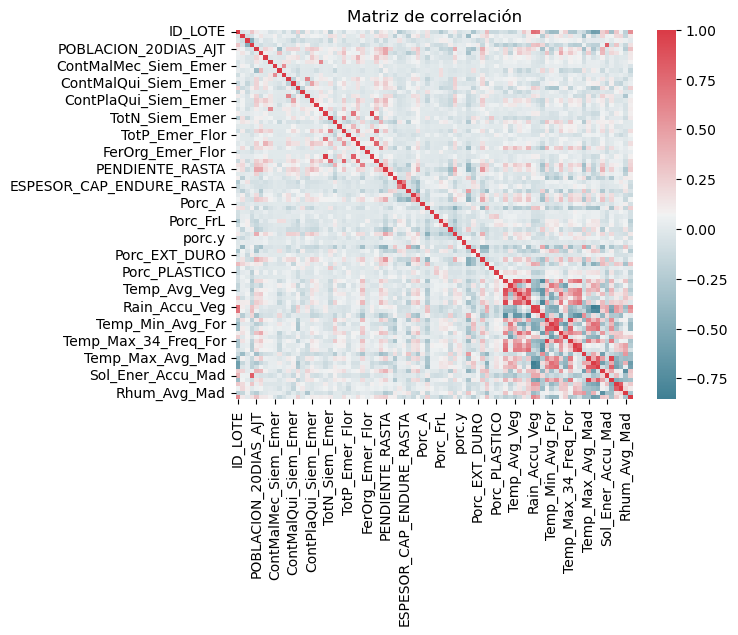

In [22]:
# Matriz de correlación para todas la caracteristicas numericas de la Vista minable
# ======================================================================================
mat_corr = df[numerical_features].corr()
sns.heatmap(mat_corr,cmap=sns.diverging_palette(220, 10, as_cmap=True))
plt.title("Matriz de correlación")

**Nota** De manera similar a lo evidenciado en los mapas de correlación por grupos de variables, se observa altas correlaciones principalmente para las variables relacionadas con el clima

## 2. Analisis Univariado
En esta segunda sesión se busca analizar como es la respuesta de la variable objetivo (Rendimientiento) vs diferentes variables de interes.
Para este caso se seleccionan especificamente algunas avriables y se analiza la distribución de la variable
respuesta 

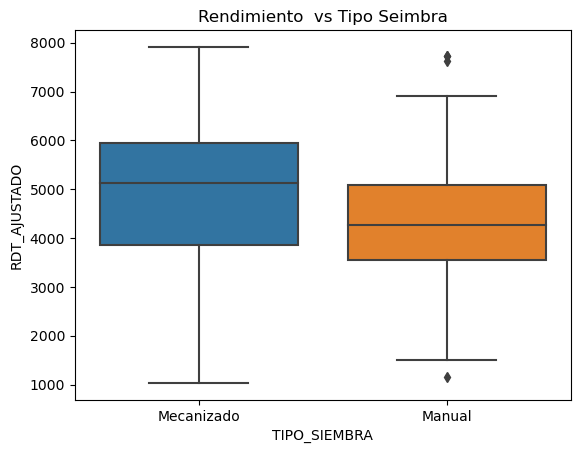

In [23]:
# Como es el rendimiento del cultivo vs TIPO SIEMBRA
# =============================================================
sns.boxplot(x='TIPO_SIEMBRA', y = 'RDT_AJUSTADO', data = df) 
plt.title("Rendimiento  vs Tipo Seimbra");

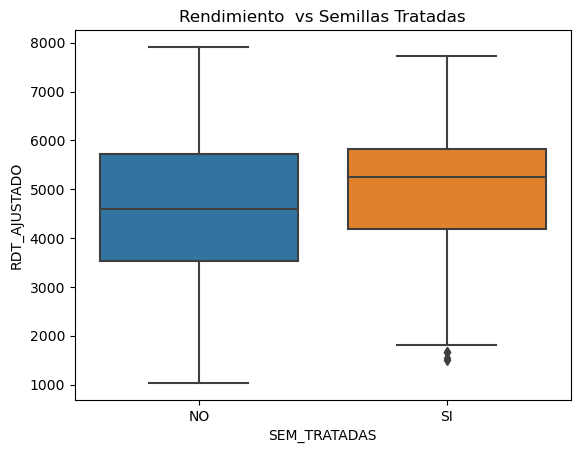

In [24]:
# RENDIMIENTO VS SEMILLAS TRATADAS
# ======================================================================
sns.boxplot(x='SEM_TRATADAS', y = 'RDT_AJUSTADO', data = df) 
plt.title("Rendimiento  vs Semillas Tratadas");

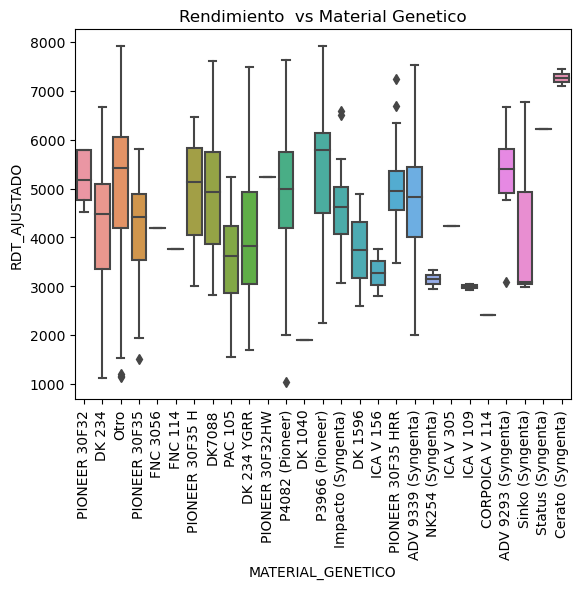

In [25]:
# Rendimiento vs MATERIAL GENETICO
# ===============================================================
sns.boxplot(x='MATERIAL_GENETICO', y = 'RDT_AJUSTADO', data = df) 
plt.title("Rendimiento  vs Material Genetico");
plt.xticks(rotation=90)
plt.show()

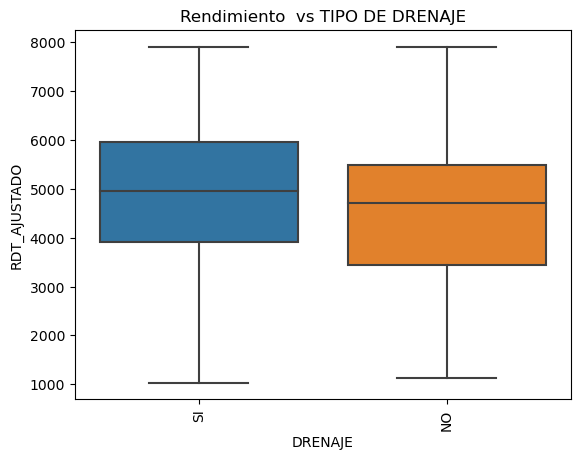

In [26]:
# Rendimiento vs MATERIAL GENETICO
# ===============================================================
sns.boxplot(x='DRENAJE', y = 'RDT_AJUSTADO', data = df) 
plt.title("Rendimiento  vs TIPO DE DRENAJE");
plt.xticks(rotation=90)
plt.show()

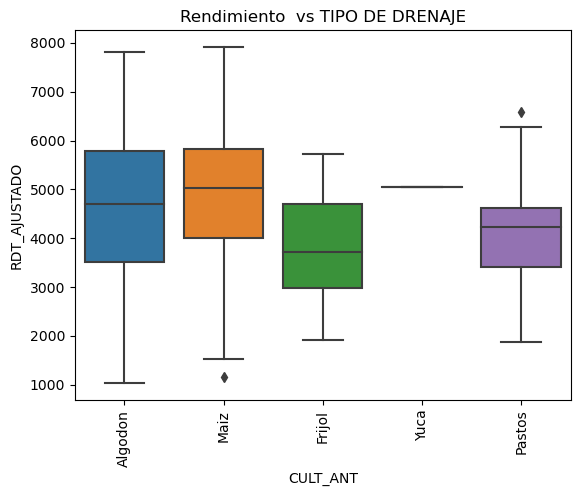

In [27]:
# Rendimiento vs CULTIVO_ANTERIOR
# ===============================================================
sns.boxplot(x='CULT_ANT', y = 'RDT_AJUSTADO', data = df) 
plt.title("Rendimiento  vs TIPO DE DRENAJE");
plt.xticks(rotation=90)
plt.show()

**Conclusion**: 
- La mediana para el tipo de siembra Mecanizado, parece ser mas alta que para el tipo de siembra manual, ademas , en la categoria manual existen algunos valores atipicos.
- La mediana para la variable semillas tratadas [SI] es mas alta que para la variable semillas tratadas [NO], ademas se observa la presencia de algunos valores atipicos
- La variable material genetico afecta considerablemente el rendimeinto de los cultivos, se observa diferentes medias deacuerdo al tipo de material.
- Para el caso del cultivo anterior se observa que que existen mayor media en el rendimiento cuando el cultivo anterior fue maiz, seguido de algon y pastos. Se observa adema que el rendimeitno mas bajo (< 4000 kg/Ha) se logra especificamente cuando el cultivo anterior fue frijol
- El tipo de drenaje afecta el rendimiento, se observa que existe mayor media para los suelos bien drenados en relación con los suelos poco drenados.

### REFERENCIAS
-  https://datavizcatalogue.com/ES/metodos/diagrama_cajas_y_bigotes.html
